# Ejercicio 6 - Parquet vs. tablas DuckDB

1. **6.1** Consulta directa a los Parquet (vista `trips` = `read_parquet`).
2. **6.2** Tabla materializada en `data/processed/taxis.duckdb` (creada con `python scripts/build_duckdb.py`).
3. **6.3 - 6.7** Resultados de `python scripts/benchmark.py`: 8 consultas x 2 modos x varios tamanos de datos.

El benchmark se ejecuta como script (tarda varios minutos) y escribe `docs/benchmark/*.csv`. Este notebook
solo carga esos resultados y los grafica, para que sea rapido de ejecutar.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd
from lab_db import DIR_SQL, connect, leer_consulta, run_query_file

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
con = connect()   # conexion en memoria + vistas de sql/00_views.sql sobre los Parquet

## 6.1 Consulta directa sobre Parquet

In [2]:
import time
t0 = time.perf_counter()
df = con.sql("SELECT file_year, taxi_type, count(*) AS viajes, round(avg(total_amount), 2) AS total_prom FROM trips GROUP BY ALL ORDER BY ALL").df()
print(f"{time.perf_counter() - t0:.2f} s leyendo directamente data/raw/*/*/*.parquet")
df

0.45 s leyendo directamente data/raw/*/*/*.parquet


,file_year,taxi_type,viajes,total_prom
0,2024,green,660218,24.26
1,2024,yellow,41169720,27.83
2,2025,green,591375,25.21
3,2025,yellow,48722602,26.91
4,2026,green,337114,25.49
5,2026,yellow,29703355,30.07


## 6.2 Tabla materializada (`data/processed/taxis.duckdb`)

In [3]:
from lab_db import BASE_MATERIALIZADA
import duckdb
db = duckdb.connect(str(BASE_MATERIALIZADA), read_only=True)
print(f"tamano: {BASE_MATERIALIZADA.stat().st_size / 1024**3:.2f} GiB")
display(db.sql("SELECT table_name, table_type FROM information_schema.tables ORDER BY table_type, table_name").df())
t0 = time.perf_counter()
df = db.sql("SELECT file_year, taxi_type, count(*) AS viajes, round(avg(total_amount), 2) AS total_prom FROM trips_tbl GROUP BY ALL ORDER BY ALL").df()
print(f"{time.perf_counter() - t0:.2f} s leyendo la tabla trips_tbl")
db.close()
df

tamano: 3.96 GiB


,table_name,table_type
0,trips_tbl,BASE TABLE
1,zones_tbl,BASE TABLE
2,green_raw,VIEW
3,trips,VIEW
4,trips_clean,VIEW
5,trips_clean_tbl,VIEW
6,yellow_raw,VIEW
7,zones,VIEW


1.51 s leyendo la tabla trips_tbl


,file_year,taxi_type,viajes,total_prom
0,2024,green,660218,24.26
1,2024,yellow,41169720,27.83
2,2025,green,591375,25.21
3,2025,yellow,48722602,26.91
4,2026,green,337114,25.49
5,2026,yellow,29703355,30.07


## 6.5 - 6.7 Resultados del benchmark

In [4]:
from lab_db import RAIZ
# resultados.csv = escenarios del Ejercicio 6; resultados_<escenario>.csv = corridas posteriores (Ejercicio 8)
bench = pd.concat([pd.read_csv(f) for f in sorted((RAIZ / "docs/benchmark").glob("resultados*.csv"))], ignore_index=True)
mat = pd.concat([pd.read_csv(f) for f in sorted((RAIZ / "docs/benchmark").glob("materializacion*.csv"))], ignore_index=True)
bench = bench.sort_values("registros", kind="stable")
mat = mat.sort_values("registros")
display(mat)
tabla = bench.pivot_table(index=["consulta", "escenario"], columns="modo", values="mediana_s", sort=False).reset_index()
tabla["parquet / tabla"] = (tabla.parquet / tabla.tabla).round(2)
tabla

,escenario,registros,mb_parquet,mb_duckdb,segundos_materializar
0,1_mes,3377403,57.3,115.0,1.11
1,2026,30040469,495.7,1008.3,19.54
2,2024+2026,71870407,1171.7,2368.8,57.46
3,2024+2025+2026,121184384,1977.0,4049.3,55.89


modo,consulta,escenario,parquet,tabla,parquet / tabla
0,b01_conteo_total.sql,1_mes,0.0063,0.0021,3.00
1,b01_conteo_total.sql,2026,0.0137,0.0110,1.25
2,b01_conteo_total.sql,2024+2026,0.0260,0.0339,0.77
3,b01_conteo_total.sql,2024+2025+2026,0.0389,0.0323,1.20
4,b02_filtro_un_dia.sql,1_mes,0.0559,0.0076,7.36
5,b02_filtro_un_dia.sql,2026,0.0640,0.0092,6.96
6,b02_filtro_un_dia.sql,2024+2026,0.1179,0.0062,19.02
7,b02_filtro_un_dia.sql,2024+2025+2026,0.0975,0.0072,13.54
8,01_viajes_por_mes.sql,1_mes,0.0871,0.0186,4.68
9,01_viajes_por_mes.sql,2026,0.2560,0.1158,2.21


### Tiempo vs. cantidad de datos

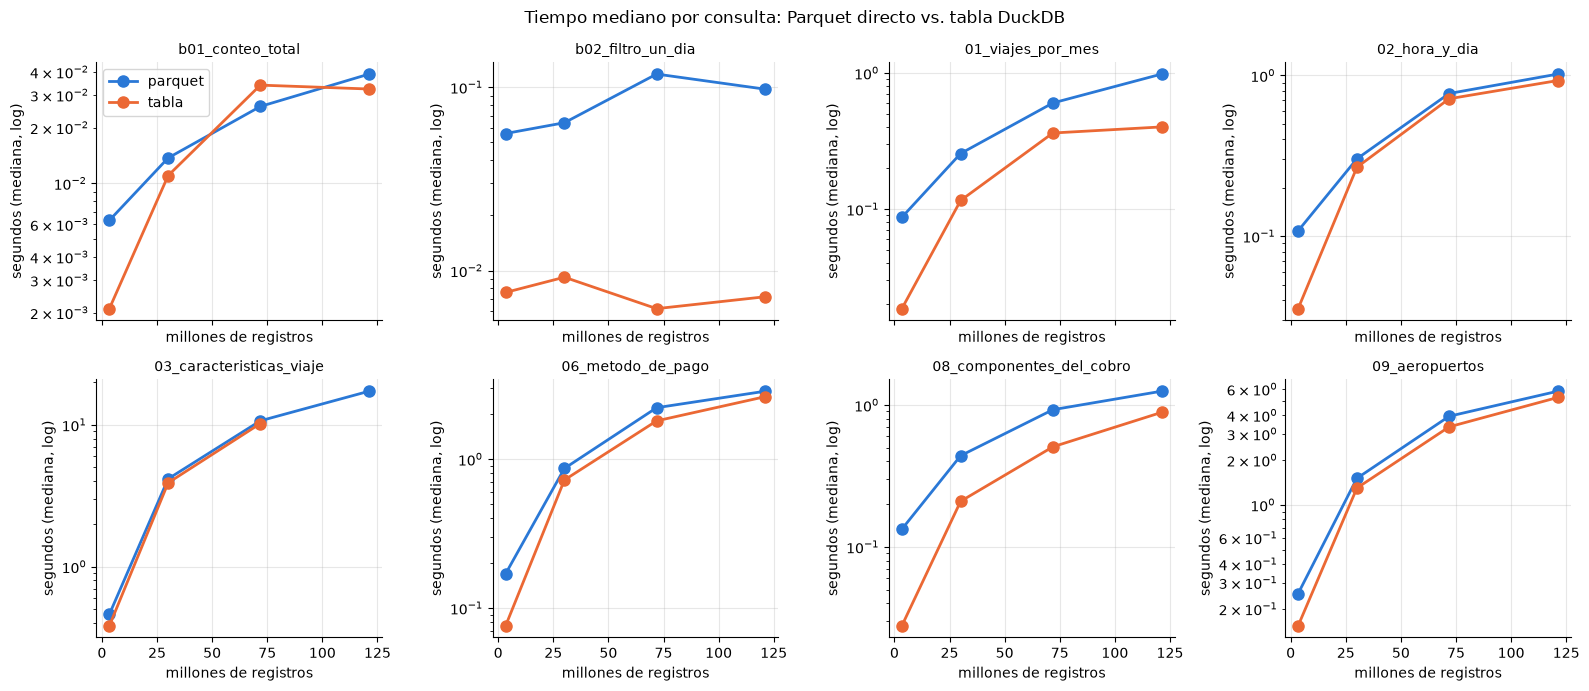

In [5]:
COLOR = {"parquet": "#2a78d6", "tabla": "#eb6834"}
consultas = bench.consulta.unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, c in zip(axes.flat, consultas):
    g = bench[bench.consulta == c]
    for modo, gg in g.groupby("modo"):
        ax.plot(gg.registros / 1e6, gg.mediana_s, marker="o", ms=8, lw=2, color=COLOR[modo], label=modo)
    ax.set_title(c.replace(".sql", ""), fontsize=10); ax.set_yscale("log")
    ax.set_xlabel("millones de registros"); ax.set_ylabel("segundos (mediana, log)")
axes.flat[0].legend()
fig.suptitle("Tiempo mediano por consulta: Parquet directo vs. tabla DuckDB")
plt.tight_layout(); plt.show()

### Cuantas veces mas lento es Parquet que la tabla (escenario mas grande)

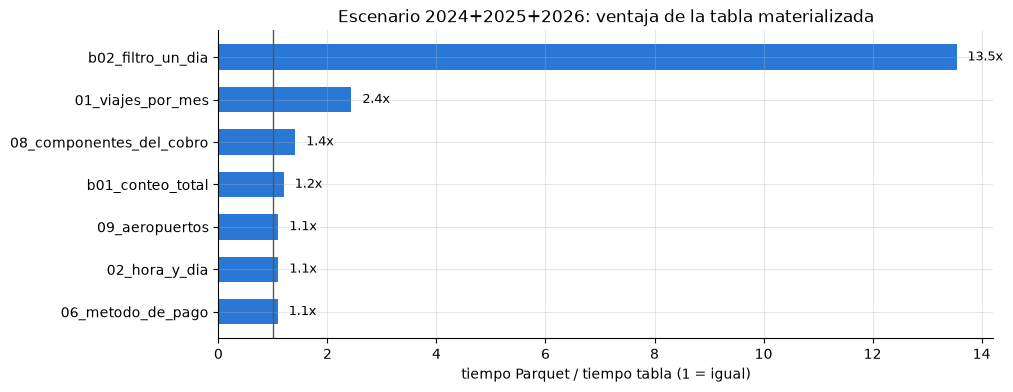

In [6]:
mayor = bench.escenario.iloc[-1]
g = tabla[tabla.escenario == mayor].dropna().sort_values("parquet / tabla")
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(g.consulta.str.replace(".sql", ""), g["parquet / tabla"], color="#2a78d6", height=0.6)
ax.axvline(1, color="#555", lw=1)
for y, v in enumerate(g["parquet / tabla"]):
    ax.text(v + 0.2, y, f"{v:.1f}x", va="center", fontsize=9)
ax.set_xlabel("tiempo Parquet / tiempo tabla (1 = igual)")
ax.set_title(f"Escenario {mayor}: ventaja de la tabla materializada"); plt.show()

### Punto de equilibrio: cuantas consultas pagan la materializacion

In [7]:
ahorro = (tabla.parquet - tabla.tabla).groupby(tabla.escenario, sort=False).mean()
eq = mat.set_index("escenario")[["registros", "segundos_materializar"]].join(ahorro.rename("ahorro_promedio_s"))
eq["consultas_para_recuperar"] = (eq.segundos_materializar / eq.ahorro_promedio_s).round(0)
eq

,registros,segundos_materializar,ahorro_promedio_s,consultas_para_recuperar
escenario,,,,
1_mes,3377403,1.11,0.071337,16.0
2026,30040469,19.54,0.134375,145.0
2024+2026,71870407,57.46,0.285050,202.0
2024+2025+2026,121184384,55.89,0.270657,206.0
